<a href="https://www.kaggle.com/code/mariammouh/mini-project-cv?scriptVersionId=303913106" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5071.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_5031.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_314.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2550.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_2234.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_3188.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1324.png
/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD/LCC_FASD_evaluation/spoof/spoof_1590.png
/

In [5]:
import os
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torchvision import transforms
from PIL import Image
import timm
from sklearn.metrics import accuracy_score, precision_score, f1_score
import matplotlib.pyplot as plt
from tqdm import tqdm

# Fine tune all


In [10]:


# ============================================================
# 1. CONFIGURATION
# ============================================================
BASE_PATH = "/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD"

CONFIG = {
    "train_dir": os.path.join(BASE_PATH, "LCC_FASD_training"),
    "val_dir":   os.path.join(BASE_PATH, "LCC_FASD_development"),
    "test_dir":  os.path.join(BASE_PATH, "LCC_FASD_evaluation"),
    "img_size":     224,
    "batch_size":   32,
    "epochs":       20,
    "lr":           1e-4,
    "weight_decay": 1e-4,
    "num_classes":  2,
    "patience":     5,   
    "device": "cuda" if torch.cuda.is_available() else "cpu",
    "seed": 42
}

print(f"Device utilisé : {CONFIG['device']}")

# ============================================================
# 2. DATASET
# ============================================================
class FaceAntiSpoofDataset(Dataset):
    def __init__(self, data_dir, transform=None):
        self.image_paths = []
        self.labels = []
        self.transform = transform

        # real -> label 1
        real_dir = os.path.join(data_dir, "real")
        for fname in os.listdir(real_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                self.image_paths.append(os.path.join(real_dir, fname))
                self.labels.append(1)

        # spoof -> label 0
        spoof_dir = os.path.join(data_dir, "spoof")
        for fname in os.listdir(spoof_dir):
            if fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                self.image_paths.append(os.path.join(spoof_dir, fname))
                self.labels.append(0)

        print(f"  {os.path.basename(data_dir)} → real: {self.labels.count(1)} | spoof: {self.labels.count(0)}")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGB")
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


# ============================================================
# 3. TRANSFORMS
# ============================================================
train_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])


# ============================================================
# 4. MODELE — FINE-TUNE ALL
# ============================================================
def build_model():
    model = timm.create_model(
        'swin_base_patch4_window7_224',
        pretrained=True,
        num_classes=CONFIG["num_classes"]
    )

    # Dégeler TOUTES les couches
    for param in model.parameters():
        param.requires_grad = True

    total = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"\nStratégie        : Fine-tune ALL")
    print(f"Paramètres entraînables : {total:,}")
    return model


# ============================================================
# 5. SAMPLER (gérer le déséquilibre des classes)
# ============================================================
def get_sampler(labels):
    class_counts = np.bincount(labels)
    weights = 1.0 / class_counts
    sample_weights = [weights[l] for l in labels]
    return WeightedRandomSampler(sample_weights, len(sample_weights))


# ============================================================
# 6. ENTRAINEMENT
# ============================================================
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    all_preds, all_labels = [], []

    for imgs, labels in tqdm(loader, desc="  Train"):
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    return total_loss / len(loader), accuracy_score(all_labels, all_preds)


# ============================================================
# 7. EVALUATION
# ============================================================
def evaluate(model, loader, criterion, device, split="Val"):
    model.eval()
    total_loss = 0
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, desc=f"  {split}"):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            loss = criterion(outputs, labels)

            total_loss += loss.item()
            all_preds.extend(outputs.argmax(dim=1).cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc  = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, zero_division=0)
    f1   = f1_score(all_labels, all_preds, zero_division=0)

    return total_loss / len(loader), acc, prec, f1

Device utilisé : cuda



📂 Chargement des données :
  LCC_FASD_training → real: 1302 | spoof: 7444
  LCC_FASD_development → real: 416 | spoof: 2590
  LCC_FASD_evaluation → real: 323 | spoof: 7312


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]


Stratégie        : Fine-tune ALL
Paramètres entraînables : 86,745,274

Epoch 1/20


  Val: 100%|██████████| 94/94 [00:37<00:00,  2.47it/s]


  Train → Loss: 0.1056 | Acc: 90.33%
  Val   → Loss: 0.1498 | Acc: 94.84% | Précision: 74.95% | F1: 83.49%
  Meilleur modèle sauvegardé (F1=83.49%)

Epoch 2/20


...

  Train → Loss: 0.0001 | Acc: 100.00%
  Val   → Loss: 0.0491 | Acc: 98.64% | Précision: 95.18% | F1: 95.07%

Epoch 20/20


  Val: 100%|██████████| 94/94 [00:37<00:00,  2.50it/s]


  Train → Loss: 0.0000 | Acc: 100.00%
  Val   → Loss: 0.0495 | Acc: 98.67% | Précision: 95.19% | F1: 95.19%

 Évaluation finale sur le Test Set :


  Test: 100%|██████████| 239/239 [01:35<00:00,  2.49it/s]



 Résultats Finaux (Fine-tune ALL)
  Accuracy  : 98.40%
  Précision : 78.80%
  F1-Score  : 81.85%


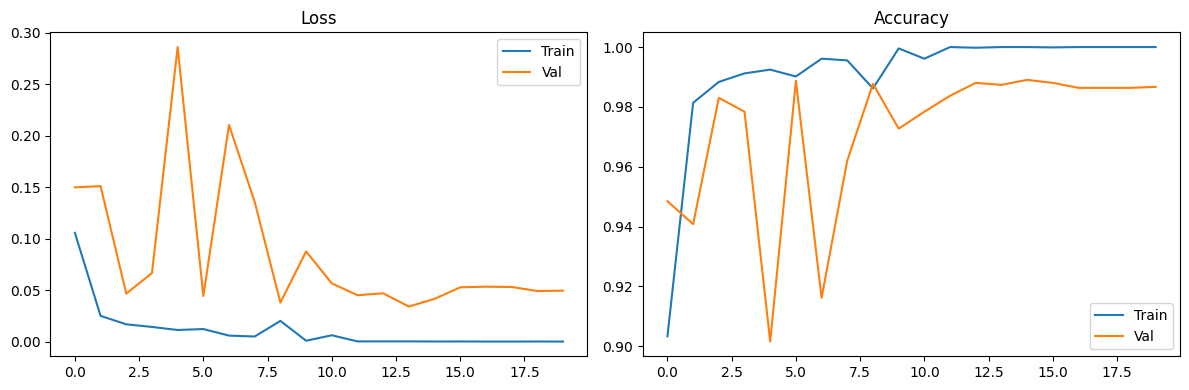

In [5]:

# ============================================================
# 8. PIPELINE PRINCIPAL
# ============================================================
def main():
    torch.manual_seed(CONFIG["seed"])

    # --- Datasets ---
    print("\n📂 Chargement des données :")
    train_dataset = FaceAntiSpoofDataset(CONFIG["train_dir"], train_transform)
    val_dataset   = FaceAntiSpoofDataset(CONFIG["val_dir"],   val_transform)
    test_dataset  = FaceAntiSpoofDataset(CONFIG["test_dir"],  val_transform)

    # --- Dataloaders ---
    sampler = get_sampler(train_dataset.labels)

    train_loader = DataLoader(train_dataset,
                              batch_size=CONFIG["batch_size"],
                              sampler=sampler,
                              num_workers=2,
                              pin_memory=True)

    val_loader   = DataLoader(val_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=False,
                              num_workers=2,
                              pin_memory=True)

    test_loader  = DataLoader(test_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=False,
                              num_workers=2,
                              pin_memory=True)

    # --- Modèle ---
    model = build_model().to(CONFIG["device"])

    # --- Loss avec poids ---
    counts = np.bincount(train_dataset.labels)
    weights = torch.tensor(1.0 / counts, dtype=torch.float).to(CONFIG["device"])
    criterion = nn.CrossEntropyLoss(weight=weights)

    # --- Optimiseur & Scheduler ---
    optimizer = torch.optim.AdamW(model.parameters(),
                                  lr=CONFIG["lr"],
                                  weight_decay=CONFIG["weight_decay"])

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"]
    )

    # --- Boucle d'entraînement ---
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_f1 = 0

    for epoch in range(CONFIG["epochs"]):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, CONFIG["device"]
        )
        val_loss, val_acc, val_prec, val_f1 = evaluate(
            model, val_loader, criterion, CONFIG["device"], "Val"
        )
        scheduler.step()

        print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
        print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | Précision: {val_prec*100:.2f}% | F1: {val_f1*100:.2f}%")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_f1 > best_f1:
            best_f1 = val_f1
            torch.save(model.state_dict(), 'best_1_finetune.pth')
            print(f"  Meilleur modèle sauvegardé (F1={best_f1*100:.2f}%)")

    # --- Test final ---
    print("\n Évaluation finale sur le Test Set :")
    model.load_state_dict(torch.load("best_finetune_all.pth"))
    _, test_acc, test_prec, test_f1 = evaluate(
        model, test_loader, criterion, CONFIG["device"], "Test"
    )
    print(f"\n Résultats Finaux (Fine-tune ALL)")
    print(f"  Accuracy  : {test_acc*100:.2f}%")
    print(f"  Précision : {test_prec*100:.2f}%")
    print(f"  F1-Score  : {test_f1*100:.2f}%")

    # --- Courbes ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"],   label="Val")
    plt.title("Loss")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train")
    plt.plot(history["val_acc"],   label="Val")
    plt.title("Accuracy")
    plt.legend()

    plt.tight_layout()
    plt.savefig("courbes_finetune_all.png")
    plt.show()


main()

In [7]:
def build_model_1_finetune():
    model = timm.create_model('swin_base_patch4_window7_224',
                               pretrained=True,
                               num_classes=CONFIG["num_classes"])
    for p in model.parameters():
        p.requires_grad = False
    for p in model.layers[-1].parameters():
        p.requires_grad = True
    for p in model.head.parameters():
        p.requires_grad = True

    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total     = sum(p.numel() for p in model.parameters())
    print(f"Stratégie : 1-Fine-tune | Entraînables: {trainable:,} / {total:,}")
    return model

model = build_model_1_finetune().to(CONFIG["device"])

model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

Stratégie : 1-Fine-tune | Entraînables: 27,306,562 / 86,745,274



📂 Chargement des données :
  LCC_FASD_training → real: 1302 | spoof: 7444
  LCC_FASD_development → real: 416 | spoof: 2590
  LCC_FASD_evaluation → real: 323 | spoof: 7312
Stratégie : 1-Fine-tune | Entraînables: 27,306,562 / 86,745,274

Epoch 1/20


  Val: 100%|██████████| 94/94 [00:43<00:00,  2.18it/s]


  Train → Loss: 0.1139 | Acc: 88.74%
  Val   → Loss: 0.1595 | Acc: 93.78% | Précision: 70.05% | F1: 81.05%
  ✅ Meilleur modèle sauvegardé (F1=81.05%)

Epoch 2/20


  Val: 100%|██████████| 94/94 [00:43<00:00,  2.18it/s]


  Train → Loss: 0.0286 | Acc: 97.80%
  Val   → Loss: 0.0578 | Acc: 98.10% | Précision: 95.67% | F1: 92.95%
  ✅ Meilleur modèle sauvegardé (F1=92.95%)

Epoch 3/20


...

  Train → Loss: 0.0040 | Acc: 99.81%
  Val   → Loss: 0.0686 | Acc: 98.60% | Précision: 99.47% | F1: 94.71%
  ⚠️ Pas d'amélioration (4/5)

Epoch 16/20


  Val: 100%|██████████| 94/94 [00:43<00:00,  2.18it/s]


  Train → Loss: 0.0013 | Acc: 99.91%
  Val   → Loss: 0.0673 | Acc: 98.87% | Précision: 99.74% | F1: 95.75%
  ⚠️ Pas d'amélioration (5/5)

⛔ Early stopping à l'epoch 16

📊 Évaluation finale sur le Test Set :


  Test: 100%|██████████| 239/239 [01:49<00:00,  2.18it/s]



🏆 Résultats Finaux (1-Fine-tune)
  Accuracy  : 98.23%
  Précision : 74.48%
  F1-Score  : 80.91%


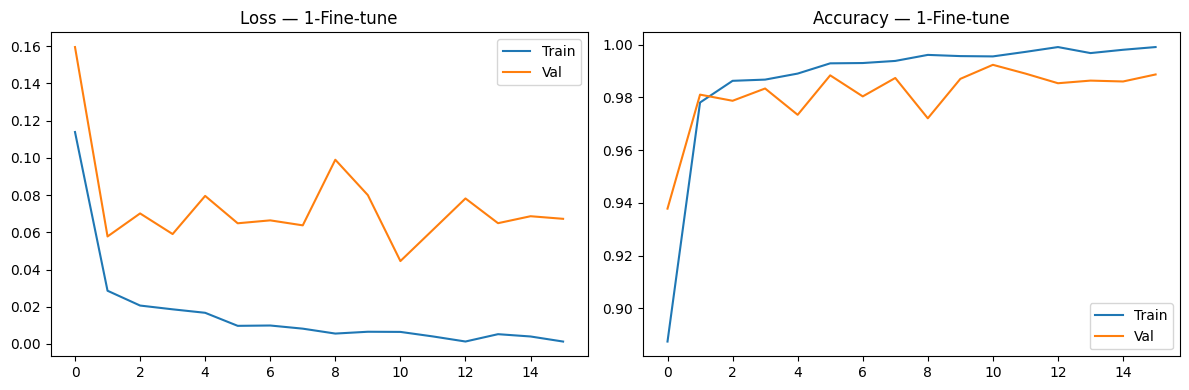

In [11]:
# ============================================================
# 8. PIPELINE PRINCIPAL
# ============================================================
def main():
    torch.manual_seed(CONFIG["seed"])

    # --- Datasets ---
    print("\n📂 Chargement des données :")
    train_dataset = FaceAntiSpoofDataset(CONFIG["train_dir"], train_transform)
    val_dataset   = FaceAntiSpoofDataset(CONFIG["val_dir"],   val_transform)
    test_dataset  = FaceAntiSpoofDataset(CONFIG["test_dir"],  val_transform)

    # --- Dataloaders ---
    sampler = get_sampler(train_dataset.labels)
    train_loader = DataLoader(train_dataset,
                              batch_size=CONFIG["batch_size"],
                              sampler=sampler,
                              num_workers=2,
                              pin_memory=True)
    val_loader   = DataLoader(val_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=False,
                              num_workers=2,
                              pin_memory=True)
    test_loader  = DataLoader(test_dataset,
                              batch_size=CONFIG["batch_size"],
                              shuffle=False,
                              num_workers=2,
                              pin_memory=True)

    # --- Modèle ---
    model = build_model_1_finetune().to(CONFIG["device"])

    # --- Loss avec poids ---
    counts = np.bincount(train_dataset.labels)
    weights = torch.tensor(1.0 / counts, dtype=torch.float).to(CONFIG["device"])
    criterion = nn.CrossEntropyLoss(weight=weights)

    # --- Optimiseur & Scheduler ---
    optimizer = torch.optim.AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=CONFIG["lr"],
        weight_decay=CONFIG["weight_decay"]
    )
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer, T_max=CONFIG["epochs"]
    )

    # --- Boucle d'entraînement ---
    history = {"train_loss": [], "val_loss": [],
               "train_acc":  [], "val_acc":  []}
    best_f1 = 0
    epochs_no_improve = 0

    for epoch in range(CONFIG["epochs"]):
        print(f"\n{'='*50}")
        print(f"Epoch {epoch+1}/{CONFIG['epochs']}")

        train_loss, train_acc = train_one_epoch(
            model, train_loader, optimizer, criterion, CONFIG["device"]
        )
        val_loss, val_acc, val_prec, val_f1 = evaluate(
            model, val_loader, criterion, CONFIG["device"], "Val"
        )
        scheduler.step()

        print(f"  Train → Loss: {train_loss:.4f} | Acc: {train_acc*100:.2f}%")
        print(f"  Val   → Loss: {val_loss:.4f} | Acc: {val_acc*100:.2f}% | Précision: {val_prec*100:.2f}% | F1: {val_f1*100:.2f}%")

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["train_acc"].append(train_acc)
        history["val_acc"].append(val_acc)

        if val_f1 > best_f1:
            best_f1 = val_f1
            epochs_no_improve = 0
            torch.save(model.state_dict(), 'best_1_finetune.pth')
            print(f"  ✅ Meilleur modèle sauvegardé (F1={best_f1*100:.2f}%)")
        else:
            epochs_no_improve += 1
            print(f"  ⚠️ Pas d'amélioration ({epochs_no_improve}/{CONFIG['patience']})")
            if epochs_no_improve >= CONFIG["patience"]:
                print(f"\n⛔ Early stopping à l'epoch {epoch+1}")
                break

    # --- Test final ---
    print("\n📊 Évaluation finale sur le Test Set :")
    model.load_state_dict(torch.load("best_1_finetune.pth"))
    _, test_acc, test_prec, test_f1 = evaluate(
        model, test_loader, criterion, CONFIG["device"], "Test"
    )
    print(f"\n🏆 Résultats Finaux (1-Fine-tune)")
    print(f"  Accuracy  : {test_acc*100:.2f}%")
    print(f"  Précision : {test_prec*100:.2f}%")
    print(f"  F1-Score  : {test_f1*100:.2f}%")

    # --- Courbes ---
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(history["train_loss"], label="Train")
    plt.plot(history["val_loss"],   label="Val")
    plt.title("Loss — 1-Fine-tune")
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(history["train_acc"], label="Train")
    plt.plot(history["val_acc"],   label="Val")
    plt.title("Accuracy — 1-Fine-tune")
    plt.legend()

    plt.tight_layout()
    plt.savefig("courbes_1_finetune.png")
    plt.show()

main()

Device : cuda

Chargement des datasets...
LCC_FASD_training — real: 1302, spoof: 7444, total: 8746
LCC_FASD_development — real: 416, spoof: 2590, total: 3006
LCC_FASD_evaluation — real: 323, spoof: 7312, total: 7635
Sampler — poids real: 0.00077, spoof: 0.00013
Fichiers trouves : []
ATTENTION : aucun fichier de poids trouve, backbone initialise aleatoirement !

Parametres entrainables : 2,050 / 86,745,274
outputs shape : torch.Size([32, 2])
labels  shape : torch.Size([32])

Epoch 1/20 ----------------
  batch 0/274 - loss: 0.7511
  batch 50/274 - loss: 0.6237
  batch 100/274 - loss: 0.5998
  batch 150/274 - loss: 0.6731
  batch 200/274 - loss: 0.5193
  batch 250/274 - loss: 0.6251
Train Loss: 0.6164  Acc: 65.87%
Val   Loss: 0.5821  Acc: 66.83%
Meilleur modele sauvegarde (val_acc=66.83%)

Epoch 2/20 ----------------
  batch 0/274 - loss: 0.6110
  batch 50/274 - loss: 0.6230
  batch 100/274 - loss: 0.6262
  batch 150/274 - loss: 0.6177
  batch 200/274 - loss: 0.7382
  batch 250/274 - los

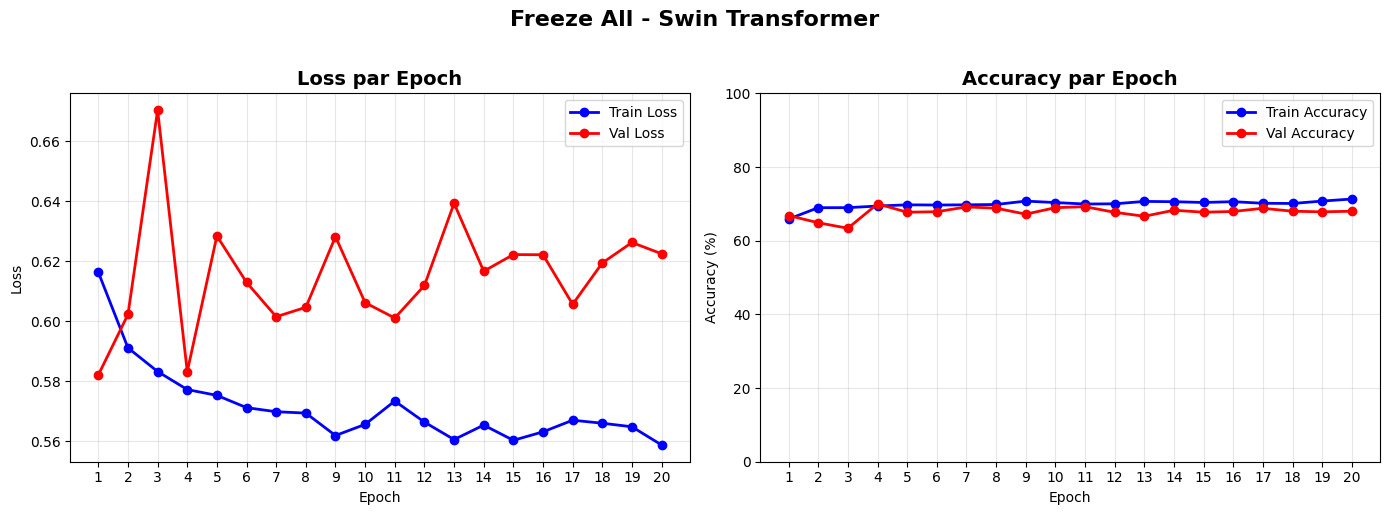

Graphique sauvegarde


In [12]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import timm
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image

# ── Config ──────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 42
torch.manual_seed(SEED)
print(f"Device : {DEVICE}")

BASE_PATH = "/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD"
CONFIG = {
    "train_dir"   : os.path.join(BASE_PATH, "LCC_FASD_training"),
    "val_dir"     : os.path.join(BASE_PATH, "LCC_FASD_development"),
    "test_dir"    : os.path.join(BASE_PATH, "LCC_FASD_evaluation"),
    "batch_size"  : 32,
    "epochs"      : 20,
    "lr"          : 1e-4,
    "weight_decay": 1e-4,
    "num_classes" : 2,
    "img_size"    : 224,
}

# ── FaceAntiSpoofDataset ─────────────────────────────────
class FaceAntiSpoofDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        class_map = {"real": 0, "spoof": 1}

        for class_name, label in class_map.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Dossier introuvable : {class_dir}")
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    self.samples.append((os.path.join(class_dir, fname), label))
                    self.labels.append(label)

        print(f"{root_dir.split('/')[-1]} — "
              f"real: {self.labels.count(0)}, "
              f"spoof: {self.labels.count(1)}, "
              f"total: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# ── get_sampler ──────────────────────────────────────────
def get_sampler(labels):
    labels         = np.array(labels, dtype=np.int64)
    counts         = np.bincount(labels)
    weights        = 1.0 / counts
    sample_weights = weights[labels]
    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float),
        num_samples = len(labels),
        replacement = True
    )
    print(f"Sampler — poids real: {weights[0]:.5f}, spoof: {weights[1]:.5f}")
    return sampler


# ── Transforms ──────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(CONFIG["img_size"]),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

# ── Datasets ────────────────────────────────────────────
print("\nChargement des datasets...")
train_dataset = FaceAntiSpoofDataset(CONFIG["train_dir"], train_transform)
val_dataset   = FaceAntiSpoofDataset(CONFIG["val_dir"],   val_transform)
test_dataset  = FaceAntiSpoofDataset(CONFIG["test_dir"],  val_transform)

# ── DataLoaders ─────────────────────────────────────────
sampler = get_sampler(train_dataset.labels)

train_loader = DataLoader(train_dataset,
                          batch_size=CONFIG["batch_size"],
                          sampler=sampler,
                          num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,
                          batch_size=CONFIG["batch_size"],
                          shuffle=False,
                          num_workers=2,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,
                          batch_size=CONFIG["batch_size"],
                          shuffle=False,
                          num_workers=2,
                          pin_memory=True)

# ── Modele Swin + Freeze All ─────────────────────────────
class SwinFreezeAll(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=False,
            num_classes=0,
            global_pool=""
        )

        # Charger les poids depuis Kaggle Models
        model_files = (
            glob.glob("/kaggle/input/swin-base-patch4-window7-224/**/*.pth",         recursive=True) +
            glob.glob("/kaggle/input/swin-base-patch4-window7-224/**/*.bin",         recursive=True) +
            glob.glob("/kaggle/input/swin-base-patch4-window7-224/**/*.safetensors", recursive=True)
        )
        print(f"Fichiers trouves : {model_files}")

        if model_files:
            state_dict = torch.load(model_files[0], map_location=DEVICE)
            # Certains fichiers ont une cle "model" ou "state_dict"
            if "model" in state_dict:
                state_dict = state_dict["model"]
            elif "state_dict" in state_dict:
                state_dict = state_dict["state_dict"]
            self.backbone.load_state_dict(state_dict, strict=False)
            print("Poids charges depuis Kaggle Models")
        else:
            print("ATTENTION : aucun fichier de poids trouve, backbone initialise aleatoirement !")

        # Geler tous les parametres du backbone
        for param in self.backbone.parameters():
            param.requires_grad = False

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = x.reshape(x.size(0), -1, 1024)
        x = x.permute(0, 2, 1)
        x = self.pool(x).squeeze(-1)
        x = self.head(x)
        return x

model = SwinFreezeAll(num_classes=CONFIG["num_classes"]).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nParametres entrainables : {trainable:,} / {total:,}")

# ── Verification shape ───────────────────────────────────
model.eval()
with torch.no_grad():
    images, labels = next(iter(train_loader))
    images = images.to(DEVICE)
    outputs = model(images)
    print(f"outputs shape : {outputs.shape}")
    print(f"labels  shape : {labels.shape}")

# ── Loss + Optimizer ────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

# ── Fonctions train / eval ───────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        if i % 50 == 0:
            print(f"  batch {i}/{len(loader)} - loss: {loss.item():.4f}")
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels


# ── Entrainement ─────────────────────────────────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0

for epoch in range(CONFIG["epochs"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']} ----------------")
    train_loss, train_acc   = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc * 100)
    val_accs.append(val_acc * 100)

    print(f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/swin_freeze_all_best.pth")
        print(f"Meilleur modele sauvegarde (val_acc={val_acc*100:.2f}%)")

# ── Rapport final ────────────────────────────────────────
print("\n========== Rapport final (Test Set) ==========")
model.load_state_dict(torch.load("/kaggle/working/swin_freeze_all_best.pth"))
_, test_acc, preds, labels_true = evaluate(model, test_loader, criterion)
print(classification_report(labels_true, preds,
      target_names=["real", "spoof"], digits=4))

torch.save(model.state_dict(), "/kaggle/working/swin_freeze_all.pth")
print("Modele final sauvegarde")

# ── Graphiques ───────────────────────────────────────────
epochs_range = range(1, CONFIG["epochs"] + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_losses, "b-o", label="Train Loss", linewidth=2)
ax1.plot(epochs_range, val_losses,   "r-o", label="Val Loss",   linewidth=2)
ax1.set_title("Loss par Epoch",    fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

ax2.plot(epochs_range, train_accs, "b-o", label="Train Accuracy", linewidth=2)
ax2.plot(epochs_range, val_accs,   "r-o", label="Val Accuracy",   linewidth=2)
ax2.set_title("Accuracy par Epoch", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)
ax2.set_ylim([0, 100])

plt.suptitle("Freeze All - Swin Transformer", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/freeze_all_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegarde")

Device : cuda

Chargement des datasets...
LCC_FASD_training — real: 1302, spoof: 7444, total: 8746
LCC_FASD_development — real: 416, spoof: 2590, total: 3006
LCC_FASD_evaluation — real: 323, spoof: 7312, total: 7635
Sampler — poids real: 0.00077, spoof: 0.00013
Fichiers trouves : []
ATTENTION : aucun fichier de poids trouve !

Parametres entrainables : 84,626,530 / 86,745,274
outputs shape : torch.Size([32, 2])
labels  shape : torch.Size([32])

Epoch 1/20 ----------------
  batch 0/274 - loss: 0.7511
  batch 50/274 - loss: 0.5497
  batch 100/274 - loss: 0.6524
  batch 150/274 - loss: 0.6749
  batch 200/274 - loss: 0.4685
  batch 250/274 - loss: 0.5645
Train Loss: 0.6409  Acc: 65.49%
Val   Loss: 0.8399  Acc: 49.67%
Meilleur modele sauvegarde (val_acc=49.67%)

Epoch 2/20 ----------------
  batch 0/274 - loss: 0.5947
  batch 50/274 - loss: 0.6589
  batch 100/274 - loss: 0.7149
  batch 150/274 - loss: 0.4596
  batch 200/274 - loss: 0.7164
  batch 250/274 - loss: 0.5214
Train Loss: 0.5723  

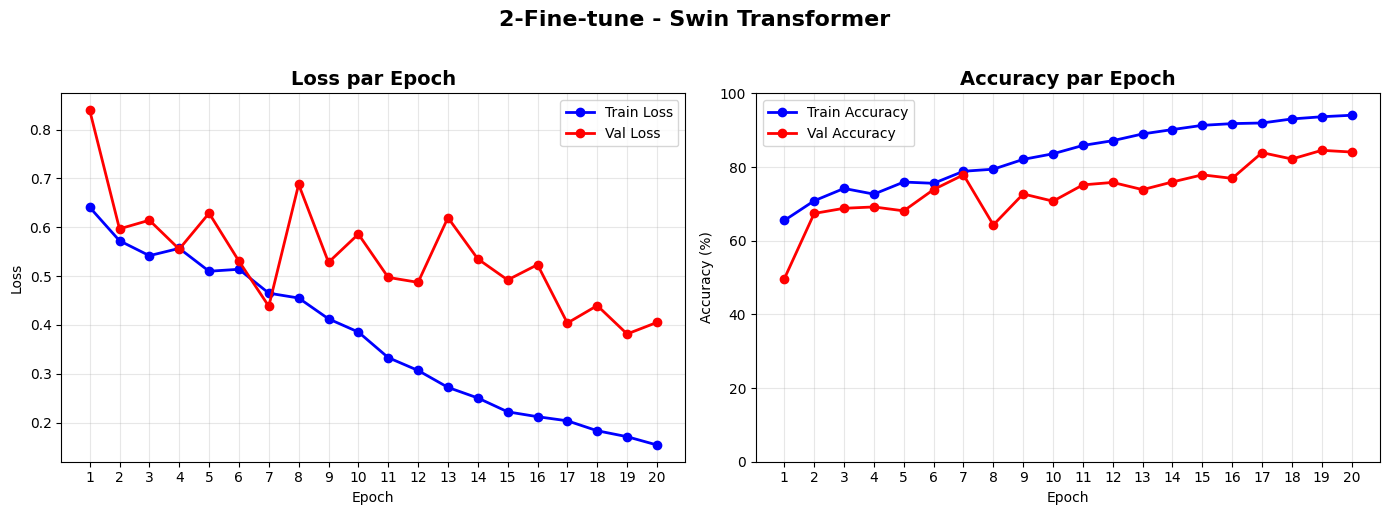

Graphique sauvegarde


In [15]:
import os
import glob
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import transforms
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
import timm
import numpy as np
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
from PIL import Image

# ── Config ──────────────────────────────────────────────
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED   = 42
torch.manual_seed(SEED)
print(f"Device : {DEVICE}")

BASE_PATH = "/kaggle/input/datasets/ahmedruhshan/lcc-fasd-casia-combined/lcc-fasd-casia/LCC_FASD"
CONFIG = {
    "train_dir"   : os.path.join(BASE_PATH, "LCC_FASD_training"),
    "val_dir"     : os.path.join(BASE_PATH, "LCC_FASD_development"),
    "test_dir"    : os.path.join(BASE_PATH, "LCC_FASD_evaluation"),
    "batch_size"  : 32,
    "epochs"      : 20,
    "lr"          : 1e-4,
    "weight_decay": 1e-4,
    "num_classes" : 2,
    "img_size"    : 224,
}

# ── FaceAntiSpoofDataset ─────────────────────────────────
class FaceAntiSpoofDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.transform = transform
        self.samples   = []
        self.labels    = []

        class_map = {"real": 0, "spoof": 1}

        for class_name, label in class_map.items():
            class_dir = os.path.join(root_dir, class_name)
            if not os.path.exists(class_dir):
                print(f"Dossier introuvable : {class_dir}")
                continue
            for fname in os.listdir(class_dir):
                if fname.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                    self.samples.append((os.path.join(class_dir, fname), label))
                    self.labels.append(label)

        print(f"{root_dir.split('/')[-1]} — "
              f"real: {self.labels.count(0)}, "
              f"spoof: {self.labels.count(1)}, "
              f"total: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


# ── get_sampler ──────────────────────────────────────────
def get_sampler(labels):
    labels         = np.array(labels, dtype=np.int64)
    counts         = np.bincount(labels)
    weights        = 1.0 / counts
    sample_weights = weights[labels]
    sampler = WeightedRandomSampler(
        weights     = torch.tensor(sample_weights, dtype=torch.float),
        num_samples = len(labels),
        replacement = True
    )
    print(f"Sampler — poids real: {weights[0]:.5f}, spoof: {weights[1]:.5f}")
    return sampler


# ── Transforms ──────────────────────────────────────────
train_transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomCrop(CONFIG["img_size"]),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((CONFIG["img_size"], CONFIG["img_size"])),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std= [0.229, 0.224, 0.225])
])

# ── Datasets ────────────────────────────────────────────
print("\nChargement des datasets...")
train_dataset = FaceAntiSpoofDataset(CONFIG["train_dir"], train_transform)
val_dataset   = FaceAntiSpoofDataset(CONFIG["val_dir"],   val_transform)
test_dataset  = FaceAntiSpoofDataset(CONFIG["test_dir"],  val_transform)

# ── DataLoaders ─────────────────────────────────────────
sampler = get_sampler(train_dataset.labels)

train_loader = DataLoader(train_dataset,
                          batch_size=CONFIG["batch_size"],
                          sampler=sampler,
                          num_workers=2,
                          pin_memory=True)
val_loader   = DataLoader(val_dataset,
                          batch_size=CONFIG["batch_size"],
                          shuffle=False,
                          num_workers=2,
                          pin_memory=True)
test_loader  = DataLoader(test_dataset,
                          batch_size=CONFIG["batch_size"],
                          shuffle=False,
                          num_workers=2,
                          pin_memory=True)

# ── Modele Swin + 2-Fine-tune ────────────────────────────
# 2-Fine-tune = Couche 3 + Couche 4 + Tete apprennent
# Couche 1 + Couche 2 restent gelees

class Swin2FineTune(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = timm.create_model(
            "swin_base_patch4_window7_224",
            pretrained=False,
            num_classes=0,
            global_pool=""
        )

        # Charger les poids depuis Kaggle Models
        model_files = (
            glob.glob("/kaggle/input/swin-base-patch4-window7-224/**/*.pth",         recursive=True) +
            glob.glob("/kaggle/input/swin-base-patch4-window7-224/**/*.bin",         recursive=True) +
            glob.glob("/kaggle/input/swin-base-patch4-window7-224/**/*.safetensors", recursive=True)
        )
        print(f"Fichiers trouves : {model_files}")

        if model_files:
            state_dict = torch.load(model_files[0], map_location=DEVICE)
            if "model" in state_dict:
                state_dict = state_dict["model"]
            elif "state_dict" in state_dict:
                state_dict = state_dict["state_dict"]
            self.backbone.load_state_dict(state_dict, strict=False)
            print("Poids charges depuis Kaggle Models")
        else:
            print("ATTENTION : aucun fichier de poids trouve !")

        # ── 2-Fine-tune : geler Couche 1 et Couche 2 uniquement ──
        # Le backbone Swin a 4 layers : layers[0], layers[1], layers[2], layers[3]

        # Geler TOUT d'abord
        for param in self.backbone.parameters():
            param.requires_grad = False

        # Degeler Couche 3 (layers[2]) et Couche 4 (layers[3])
        for param in self.backbone.layers[2].parameters():
            param.requires_grad = True

        for param in self.backbone.layers[3].parameters():
            param.requires_grad = True

        # Degeler aussi la normalisation finale
        for param in self.backbone.norm.parameters():
            param.requires_grad = True

        self.pool = nn.AdaptiveAvgPool1d(1)
        self.head = nn.Linear(1024, num_classes)

    def forward(self, x):
        x = self.backbone(x)
        x = x.reshape(x.size(0), -1, 1024)
        x = x.permute(0, 2, 1)
        x = self.pool(x).squeeze(-1)
        x = self.head(x)
        return x

model = Swin2FineTune(num_classes=CONFIG["num_classes"]).to(DEVICE)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"\nParametres entrainables : {trainable:,} / {total:,}")

# ── Verification shape ───────────────────────────────────
model.eval()
with torch.no_grad():
    images, labels = next(iter(train_loader))
    images = images.to(DEVICE)
    outputs = model(images)
    print(f"outputs shape : {outputs.shape}")
    print(f"labels  shape : {labels.shape}")

# ── Loss + Optimizer ────────────────────────────────────
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=CONFIG["lr"],
    weight_decay=CONFIG["weight_decay"]
)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", factor=0.5, patience=2
)

# ── Fonctions train / eval ───────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(images)
        loss    = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
        correct    += (outputs.argmax(1) == labels).sum().item()
        total      += labels.size(0)
        if i % 50 == 0:
            print(f"  batch {i}/{len(loader)} - loss: {loss.item():.4f}")
    return total_loss / len(loader), correct / total


def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            total_loss += loss.item()
            preds = outputs.argmax(1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    return total_loss / len(loader), correct / total, all_preds, all_labels


# ── Entrainement ─────────────────────────────────────────
train_losses, val_losses = [], []
train_accs,   val_accs   = [], []
best_val_acc = 0

for epoch in range(CONFIG["epochs"]):
    print(f"\nEpoch {epoch+1}/{CONFIG['epochs']} ----------------")
    train_loss, train_acc   = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion)
    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc * 100)
    val_accs.append(val_acc * 100)

    print(f"Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%")
    print(f"Val   Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "/kaggle/working/swin_2finetune_best.pth")
        print(f"Meilleur modele sauvegarde (val_acc={val_acc*100:.2f}%)")

# ── Rapport final ────────────────────────────────────────
print("\n========== Rapport final (Test Set) ==========")
model.load_state_dict(torch.load("/kaggle/working/swin_2finetune_best.pth"))
_, test_acc, preds, labels_true = evaluate(model, test_loader, criterion)
print(classification_report(labels_true, preds,
      target_names=["real", "spoof"], digits=4))

torch.save(model.state_dict(), "/kaggle/working/swin_2finetune.pth")
print("Modele final sauvegarde")

# ── Graphiques ───────────────────────────────────────────
epochs_range = range(1, CONFIG["epochs"] + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_range, train_losses, "b-o", label="Train Loss", linewidth=2)
ax1.plot(epochs_range, val_losses,   "r-o", label="Val Loss",   linewidth=2)
ax1.set_title("Loss par Epoch",    fontsize=14, fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Loss")
ax1.legend()
ax1.grid(True, alpha=0.3)
ax1.set_xticks(epochs_range)

ax2.plot(epochs_range, train_accs, "b-o", label="Train Accuracy", linewidth=2)
ax2.plot(epochs_range, val_accs,   "r-o", label="Val Accuracy",   linewidth=2)
ax2.set_title("Accuracy par Epoch", fontsize=14, fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Accuracy (%)")
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xticks(epochs_range)
ax2.set_ylim([0, 100])

plt.suptitle("2-Fine-tune - Swin Transformer", fontsize=16, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/2finetune_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Graphique sauvegarde")